<a href="https://colab.research.google.com/github/alyPoint/CEFET---Processamento-de-Sinais-I-140826/blob/main/Pratica_4/DSP_1_PRATICA_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pratica 4 exercício 1

<>:42: SyntaxWarning: invalid escape sequence '\o'
<>:43: SyntaxWarning: invalid escape sequence '\o'
<>:45: SyntaxWarning: invalid escape sequence '\p'
<>:45: SyntaxWarning: invalid escape sequence '\p'
<>:45: SyntaxWarning: invalid escape sequence '\p'
<>:45: SyntaxWarning: invalid escape sequence '\p'
<>:53: SyntaxWarning: invalid escape sequence '\o'
<>:56: SyntaxWarning: invalid escape sequence '\p'
<>:56: SyntaxWarning: invalid escape sequence '\p'
<>:56: SyntaxWarning: invalid escape sequence '\p'
<>:56: SyntaxWarning: invalid escape sequence '\p'
<>:42: SyntaxWarning: invalid escape sequence '\o'
<>:43: SyntaxWarning: invalid escape sequence '\o'
<>:45: SyntaxWarning: invalid escape sequence '\p'
<>:45: SyntaxWarning: invalid escape sequence '\p'
<>:45: SyntaxWarning: invalid escape sequence '\p'
<>:45: SyntaxWarning: invalid escape sequence '\p'
<>:53: SyntaxWarning: invalid escape sequence '\o'
<>:56: SyntaxWarning: invalid escape sequence '\p'
<>:56: SyntaxWarning: invalid e

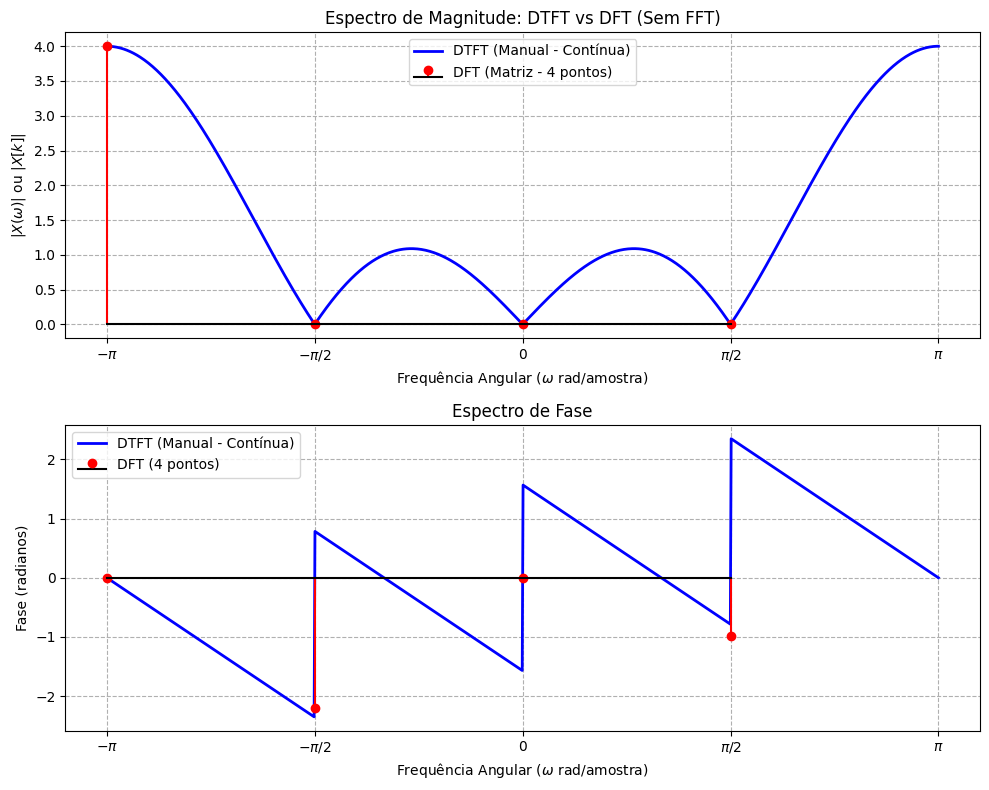

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definindo o sinal x[n]
x = np.array([1, -1, 1, -1])
N = len(x)
n = np.arange(N)  # Vetor de índices temporais [0, 1, 2, 3]

# 2. Calculando a DTFT manualmente (Frequência Contínua aproximada)
w = np.linspace(-np.pi, np.pi, 1000)  # Eixo contínuo de -pi a pi
X_dtft = np.zeros(len(w), dtype=complex)

for i, freq in enumerate(w):
    # Aplicação direta da fórmula: X(e^jw) = sum( x[n] * e^(-j * w * n) )
    X_dtft[i] = np.sum(x * np.exp(-1j * freq * n))

# 3. Calculando a DFT de 4 pontos manualmente (Usando a Matriz de Vandermonde)
k = np.arange(N)  # Vetor de índices de frequência [0, 1, 2, 3]
# Criando a matriz de expoentes (n amostras x k frequências)
nk = n.reshape((N, 1)) * k.reshape((1, N))
# Matriz de transformação da DFT: W[n,k] = e^(-j * 2 * pi * n * k / N)
W = np.exp(-1j * 2 * np.pi * nk / N)
# Multiplicação matricial para obter o vetor X[k]
X_dft = np.dot(x, W)

# Frequências digitais correspondentes aos bins da DFT: k * (2 * pi / N)
w_dft = k * (2 * np.pi / N)
# Ajustando as frequências da DFT para a janela de -pi a pi (para sobrepor no gráfico)
w_dft = (w_dft + np.pi) % (2 * np.pi) - np.pi
# Reordenando para plotar corretamente de forma crescente no eixo X
idx = np.argsort(w_dft)
w_dft_sorted = w_dft[idx]
X_dft_sorted = X_dft[idx]

# 4. Criando os Gráficos (Magnitude e Fase)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# --- Gráfico de Magnitude ---
ax1.plot(w, np.abs(X_dtft), label='DTFT (Manual - Contínua)', color='blue', linewidth=2)
ax1.stem(w_dft_sorted, np.abs(X_dft_sorted), linefmt='r-', markerfmt='ro', basefmt='k-', label='DFT (Matriz - 4 pontos)')
ax1.set_title('Espectro de Magnitude: DTFT vs DFT (Sem FFT)')
ax1.set_xlabel('Frequência Angular ($\omega$ rad/amostra)')
ax1.set_ylabel('$|X(\omega)|$ ou $|X[k]|$')
ax1.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax1.set_xticklabels(['$-\pi$', '$-\pi/2$', '0', '$\pi/2$', '$\pi$'])
ax1.grid(True, linestyle='--')
ax1.legend()

# --- Gráfico de Fase ---
ax2.plot(w, np.angle(X_dtft), label='DTFT (Manual - Contínua)', color='blue', linewidth=2)
ax2.stem(w_dft_sorted, np.angle(X_dft_sorted), linefmt='r-', markerfmt='ro', basefmt='k-', label='DFT (4 pontos)')
ax2.set_title('Espectro de Fase')
ax2.set_xlabel('Frequência Angular ($\omega$ rad/amostra)')
ax2.set_ylabel('Fase (radianos)')
ax2.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax2.set_xticklabels(['$-\pi$', '$-\pi/2$', '0', '$\pi/2$', '$\pi$'])
ax2.grid(True, linestyle='--')
ax2.legend()

plt.tight_layout()
plt.show()

Pratica 4 exercício 2

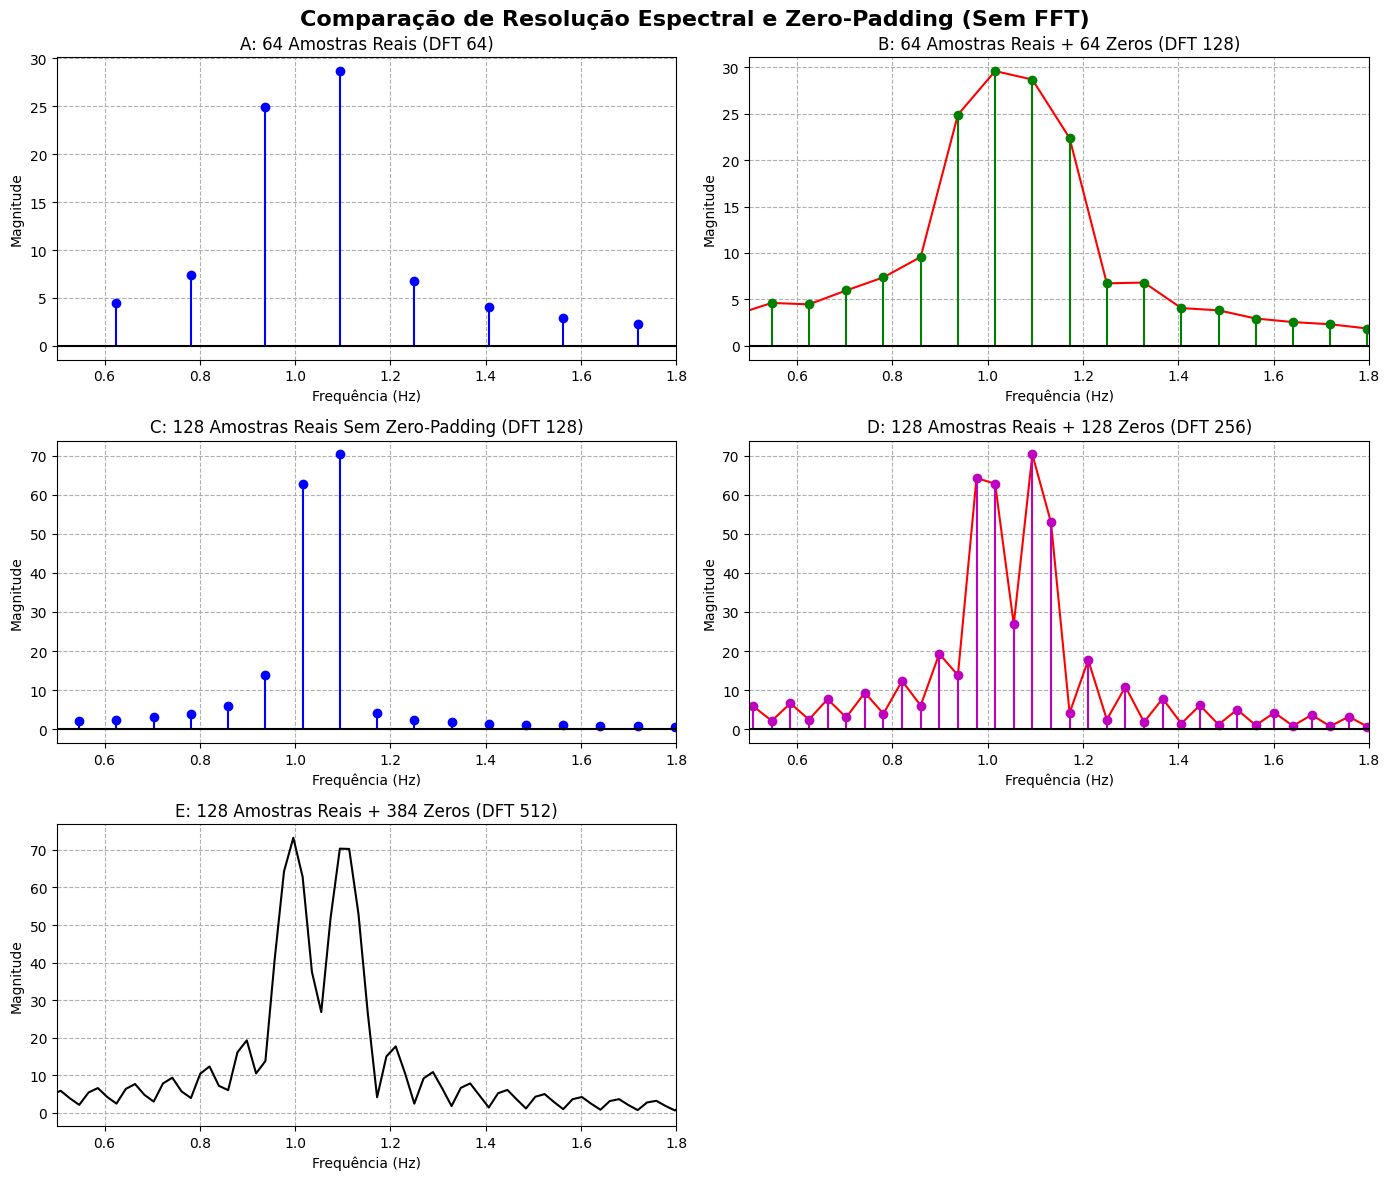

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Configurações iniciais
fs = 10.0  # Frequência de amostragem

def dft_manual(x, N_dft):
    """Calcula a DFT de N_dft pontos sem utilizar FFT"""
    N_x = len(x)
    # Se o tamanho da DFT for maior que o sinal, aplica zero-padding
    if N_dft > N_x:
        x_pad = np.concatenate([x, np.zeros(N_dft - N_x)])
    else:
        x_pad = x[:N_dft]

    n = np.arange(N_dft)
    k = np.arange(N_dft)
    nk = n.reshape((N_dft, 1)) * k.reshape((1, N_dft))
    W = np.exp(-1j * 2 * np.pi * nk / N_dft)

    X = np.dot(x_pad, W)
    freqs = k * (fs / N_dft)
    return freqs[:N_dft//2], np.abs(X[:N_dft//2]) # Retorna apenas a metade positiva

# --- GERAÇÃO DOS SINAIS ---
# 1. 64 amostras reais
t64 = np.arange(64) / fs
x64 = np.sin(2 * np.pi * t64) + np.sin(2.2 * np.pi * t64)

# 2. 128 amostras reais
t128 = np.arange(128) / fs
x128 = np.sin(2 * np.pi * t128) + np.sin(2.2 * np.pi * t128)

# --- CÁLCULO DOS 5 CASOS ---
f1, X1 = dft_manual(x64, 64)       # 64 amostras reais (DFT 64)
f2, X2 = dft_manual(x64, 128)      # 64 amostras + 64 zeros (DFT 128)
f3, X3 = dft_manual(x128, 128)     # 128 amostras reais (DFT 128)
f4, X4 = dft_manual(x128, 256)     # 128 amostras + 128 zeros (DFT 256)
f5, X5 = dft_manual(x128, 512)     # 128 amostras + 384 zeros (DFT 512)

# --- PLOTAGEM DOS GRÁFICOS ---
fig, axs = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Comparação de Resolução Espectral e Zero-Padding (Sem FFT)', fontsize=16, fontweight='bold')

# Grupo 1: Janela de observação de 64 amostras
axs[0, 0].stem(f1, X1, linefmt='b-', markerfmt='bo', basefmt='k-')
axs[0, 0].set_title('A: 64 Amostras Reais (DFT 64)')

axs[0, 1].plot(f2, X2, 'r-', label='Envelope')
axs[0, 1].stem(f2, X2, linefmt='g-', markerfmt='go', basefmt='k-')
axs[0, 1].set_title('B: 64 Amostras Reais + 64 Zeros (DFT 128)')

# Grupo 2: Janela de observação ampliada para 128 amostras reais
axs[1, 0].stem(f3, X3, linefmt='b-', markerfmt='bo', basefmt='k-')
axs[1, 0].set_title('C: 128 Amostras Reais Sem Zero-Padding (DFT 128)')

# Grupo 3: Efeito de Zero-Padding progressivo em 128 amostras
axs[1, 1].plot(f4, X4, 'r-', label='Envelope')
axs[1, 1].stem(f4, X4, linefmt='m-', markerfmt='mo', basefmt='k-')
axs[1, 1].set_title('D: 128 Amostras Reais + 128 Zeros (DFT 256)')

axs[2, 0].plot(f5, X5, 'k-', linewidth=1.5)
axs[2, 0].set_title('E: 128 Amostras Reais + 384 Zeros (DFT 512)')

# Ajustes estéticos gerais
for ax in axs.flat:
    ax.set_xlim([0.5, 1.8]) # Foco na região das frequências do sinal (1.0 e 1.1 Hz)
    ax.set_xlabel('Frequência (Hz)')
    ax.set_ylabel('Magnitude')
    ax.grid(True, linestyle='--')

# Remover o último subplot vazio (posição 2,1)
fig.delaxes(axs[2, 1])

plt.tight_layout()
plt.show()

Pratica 4 exercício 3

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import google.colab as clb
import soundfile as sf
from google.colab import files
import array

r = array.array('f', [99.5/100, 99/100, 90/100, 75/100, 50/100])

files.upload()


Saving handel.wav to handel (1).wav


{'handel (1).wav': b"RIFFV;\x02\x00WAVEfmt \x10\x00\x00\x00\x01\x00\x01\x00\x00 \x00\x00\x00@\x00\x00\x02\x00\x10\x00data2;\x02\x00\x00\x006\xffe\xf6\x02\xfc\xc9\x00\xe0\x04i\x02\xcc\xfc\x02\xfce\xf6\xe4\xef\x87\xed\xcd\xe8\x9e\xe7e\xf6_\xfe\x1f\xfbe\xf6\x00\x00\x9a\t\x1b\x102\x17B\x13\x1b\x10d\n=\x07\x00\x00\xf8\xf7\xd5\xf3\x1f\xfb6\xff\x96\xfde\xf6\xd5\xf3e\xf6e\xf6\x02\xfc\xc2\xf8\x96\xfd3\x03=\x07=\x073\x03\x96\xfd3\x03\xbd\r\x1b\x10d\n\xfd\x03\xc9\x00\x02\xfc\xc9\x006\xff3\x03Q\x0fB\x13\xd5\x14\xd5\x14s\x06\x00\x00\xc9\x006\xff\xd5\xf3\xe4\xef\xe4\xefx\xf1\x8c\xf96\xff\x96\xfdi\x02d\nx\x12B\x13\xbd\rs\x06=\x07Q\x0f\x9a\t3\x03_\xfei\x023\x03=\x07=\x07s\x063\x036\xff\xcc\xfc\x8c\xf9\x87\xed\x0b\xf3\xaa\x05\xd1\x08\xfd\x036\xff\x00\x00\x00\x00\x07\x08*\x0cd\n*\x0c\xd1\x08\xe0\x04i\x02\xd5\xf3B\xf2\x96\xfds\x06s\x06\xaa\x05\xa0\x01\xc2\xf8.\xf7e\xf6\x9b\xf5e\xf6B\xf2\x9f\xf4.\xf7\x0b\xf3\xbd\xece\xf6=\x07`\x0b\x1b\x10Q\x0f=\x073\x03\xd1\x08s\x063\x03i\x02\xfd\x03s\x06\xa0\x01\xf8\xf7\

In [17]:
#TESTE

import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from google.colab import files
import IPython.display as ipd

# 1. Upload do seu arquivo 'handel.wav'
print("Por favor, selecione o arquivo 'handel.wav' do seu computador:")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# 2. Leitura do áudio real usando a biblioteca Soundfile
signal, fs = sf.read(file_name)

# Garante que o sinal seja tratado como float e normalizado entre -1 e 1
signal = signal.astype(float)
if np.max(np.abs(signal)) > 0:
    signal = signal / np.max(np.abs(signal))

# Se o áudio for estéreo (2 canais), converte para mono pegando apenas o canal 0
if len(signal.shape) > 1:
    signal = signal[:, 0]

# --- FUNÇÕES DFT E IDFT MATRICIAIS (SEM FFT) ---
def dft_manual_block(block):
    N = len(block)
    n = np.arange(N)
    k = np.arange(N)
    nk = n.reshape((N, 1)) * k.reshape((1, N))
    W = np.exp(-1j * 2 * np.pi * nk / N)
    return np.dot(block, W)

def idft_manual_block(X_block):
    N = len(X_block)
    n = np.arange(N)
    k = np.arange(N)
    nk = n.reshape((N, 1)) * k.reshape((1, N))
    W_inv = np.exp(1j * 2 * np.pi * nk / N) / N
    return np.real(np.dot(X_block, W_inv))

# --- ALGORITMO DE COMPRESSÃO POR LIMIAR DE ENERGIA ---
def compress_block(X_block, r_ratio):
    energy_per_coeff = np.abs(X_block) ** 2
    sorted_indices = np.argsort(energy_per_coeff)[::-1]

    total_energy = np.sum(energy_per_coeff)
    target_energy = total_energy * r_ratio

    mask = np.zeros_like(X_block, dtype=bool)
    accumulated_energy = 0.0
    for idx in sorted_indices:
        accumulated_energy += energy_per_coeff[idx]
        mask[idx] = True
        if accumulated_energy >= target_energy:
            break

    X_compressed = X_block * mask
    return X_compressed

# --- PROCESSAMENTO EM BLOCOS ---
block_size = 256
num_blocks = len(signal) // block_size
truncated_signal = signal[:num_blocks * block_size]

r_values = [0.995, 0.990, 0.900, 0.750, 0.500]
reconstructed_signals = {}

print("\nProcessando a compressão em blocos (isso pode levar alguns segundos)...")
for r in r_values:
    reconstructed = np.zeros_like(truncated_signal)
    for b in range(num_blocks):
        block = truncated_signal[b*block_size : (b+1)*block_size]
        X_block = dft_manual_block(block)
        X_comp = compress_block(X_block, r)
        reconstructed[b*block_size : (b+1)*block_size] = idft_manual_block(X_comp)

    reconstructed_signals[r] = reconstructed
print("Processamento concluído!\n")

# --- REPRODUÇÃO DOS ÁUDIOS ---
print("--- Áudio Original ---")
ipd.display(ipd.Audio(truncated_signal, rate=fs))

for r in r_values:
    print(f"\n--- Áudio Comprimido com r = {r*100}% ---")
    ipd.display(ipd.Audio(reconstructed_signals[r], rate=fs))

    #os seguintes áudios: original, r = 99.5% e r = 99%, não possuem diferenças notáveis.
    #a partir do r = 99% para baixo, dá para perceber um som meio digital.

Por favor, selecione o arquivo 'handel.wav' do seu computador:


Saving handel.wav to handel (2).wav

Processando a compressão em blocos (isso pode levar alguns segundos)...
Processamento concluído!

--- Áudio Original ---



--- Áudio Comprimido com r = 99.5% ---



--- Áudio Comprimido com r = 99.0% ---



--- Áudio Comprimido com r = 90.0% ---



--- Áudio Comprimido com r = 75.0% ---



--- Áudio Comprimido com r = 50.0% ---


Pratica 4 exercício 4

Pratica 4 exercício 5